### Análisis de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dev_path = "data/raw/casas_dev.csv"
test_path = "data/raw/casas_test.csv"

casas_dev_df = pd.read_csv(dev_path)
casas_test_df = pd.read_csv(test_path)

In [3]:
print('shape = ', casas_dev_df.shape)
casas_dev_df.sample(5)

shape =  (900, 9)


,area,area_units,is_house,has_pool,age,price,lat,lon,rooms
679,65.0,m2,1,0,11.0,119.0,-34.630404,-58.319213,2.0
429,40.0,m2,0,0,4.0,67.0,-34.597718,-58.345091,1.0
74,807.0,sqft,0,0,12.0,561.0,40.706789,-74.018348,2.0
549,73.0,m2,1,1,12.0,139.0,-34.616676,-58.309189,2.0
240,134.0,m2,1,0,7.0,268.0,-34.567559,-58.431330,4.0


In [4]:
print('shape = ', casas_test_df.shape)
casas_test_df.sample(5)

shape =  (100, 9)


,area,area_units,is_house,has_pool,age,price,lat,lon,rooms
25,614.0,sqft,0,0,5.0,430.0,40.735966,-74.006615,2.0
39,90.0,m2,1,1,8.0,191.0,-34.645146,-58.413851,2.0
14,1033.0,sqft,0,0,11.0,716.0,40.695764,-74.013572,3.0
10,872.0,sqft,0,0,12.0,588.0,40.740374,-74.049542,2.0
55,667.0,sqft,0,0,6.0,465.0,40.700456,-74.052172,2.0


### 1. Exploración de datos

El orden de los incisos correspondientes al ejercicio 1 fueron alterados por cuestiones de eficacia y buenas prácticas.

1.1 primera parte) Analizamos los valores faltantes en los datasets.

In [5]:
from src.utils import missing_percentages, missing_values

In [6]:
print("Dev Set")
missing_values(casas_dev_df)
missing_percentages(casas_dev_df)


Dev Set

Valores faltantes por columna:
area            0
area_units      0
is_house        0
has_pool        0
age           130
price           0
lat             0
lon             0
rooms          72
dtype: int64
Valores NaN en 'age': 130 sobre un total de 900 filas (14.44%)
Valores NaN en 'rooms': 72 sobre un total de 900 filas (8.00%)


Dropear 14.44% y/o 8% de los datos por una feature faltante sería desperdiciar mucha información por lo que intentaremos estimar estos valores faltantes. Para eso, anaelicemos el resto de las features y sus correlaciones.

In [7]:
print("Test Set")
missing_values(casas_test_df)
missing_percentages(casas_test_df)

Test Set

Valores faltantes por columna:
area           0
area_units     0
is_house       0
has_pool       0
age           16
price          0
lat            0
lon            0
rooms          4
dtype: int64
Valores NaN en 'age': 16 sobre un total de 100 filas (16.00%)
Valores NaN en 'rooms': 4 sobre un total de 100 filas (4.00%)


##### Revisión de unidades

In [8]:
print(casas_dev_df['area_units'].value_counts())

area_units
m2      463
sqft    437
Name: count, dtype: int64


Conversión/unificación de unidades

In [9]:
print(casas_test_df['area_units'].value_counts())

area_units
m2      53
sqft    47
Name: count, dtype: int64


In [10]:
from src.preprocessing import area_units_conversion

In [11]:
units_converted_dev_df = area_units_conversion(casas_dev_df)

In [12]:
units_converted_test_df = area_units_conversion(casas_test_df)

Ahora sí podemos visualizar las distribuciones de dev

#### 1.2)

In [13]:
from src.plotting import plot_distributions, plot_scatter_matrix, plot_correlation

#### Dev Set

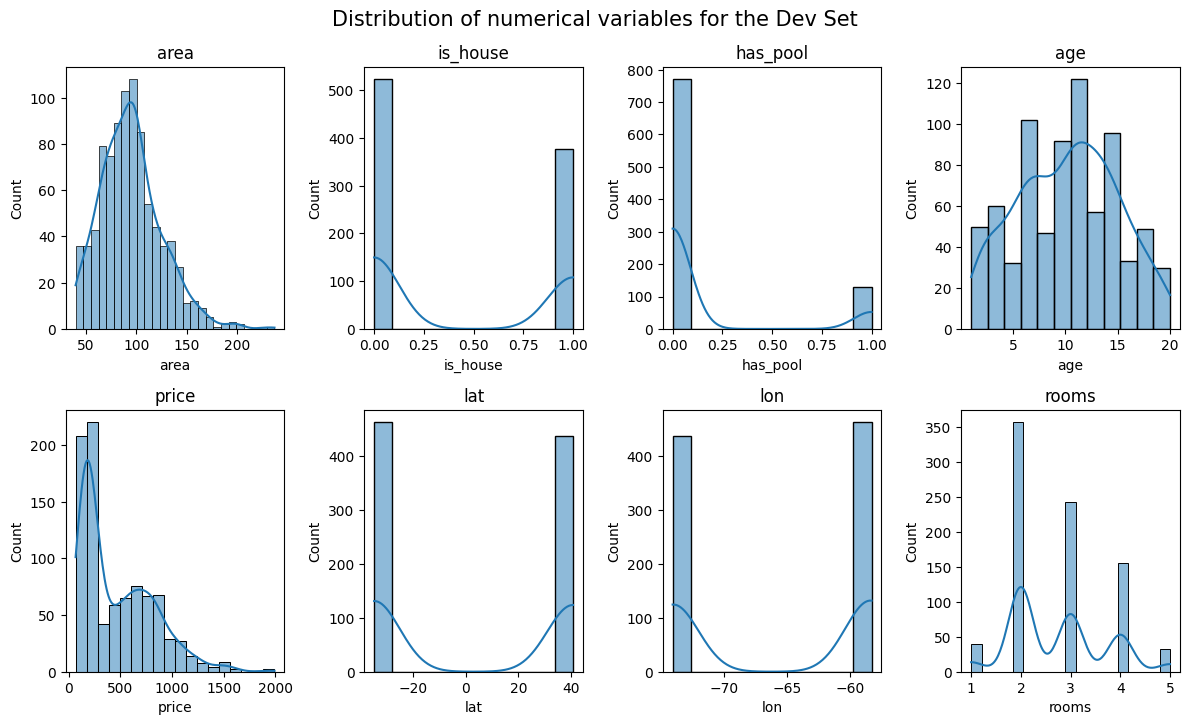

In [14]:
plot_distributions(units_converted_dev_df, "Dev")

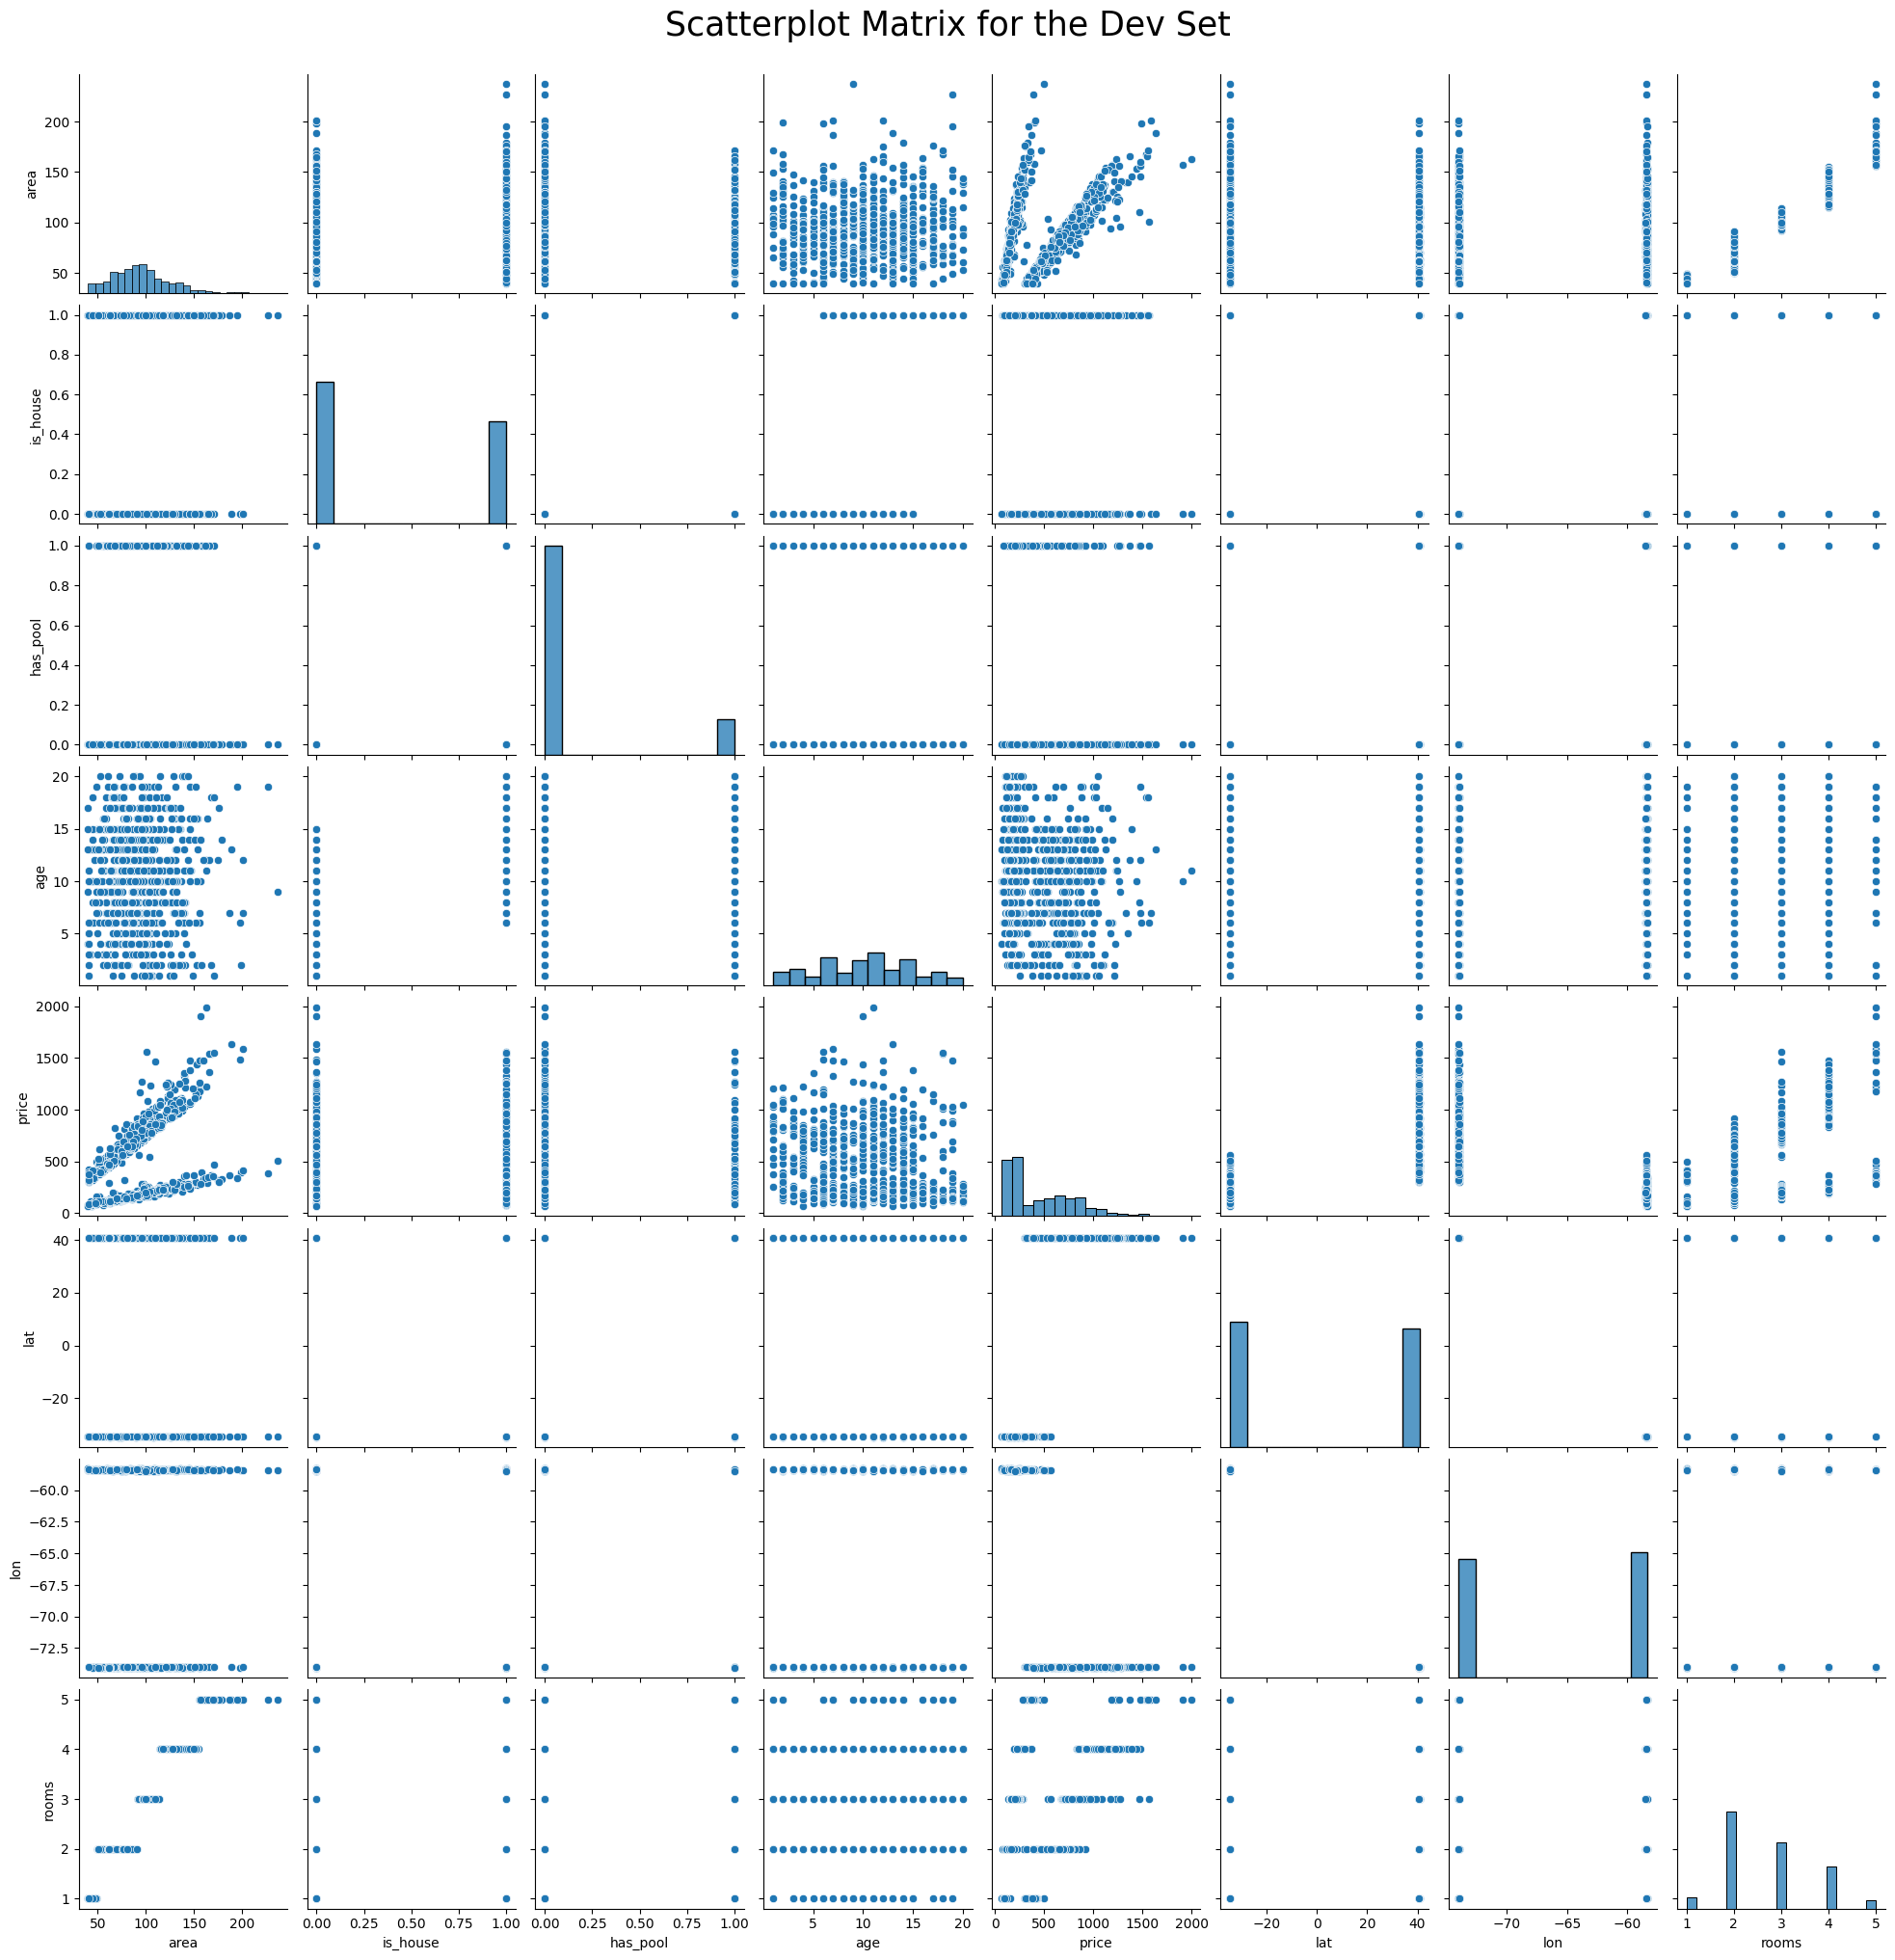

In [15]:
plot_scatter_matrix(units_converted_dev_df, "Dev")

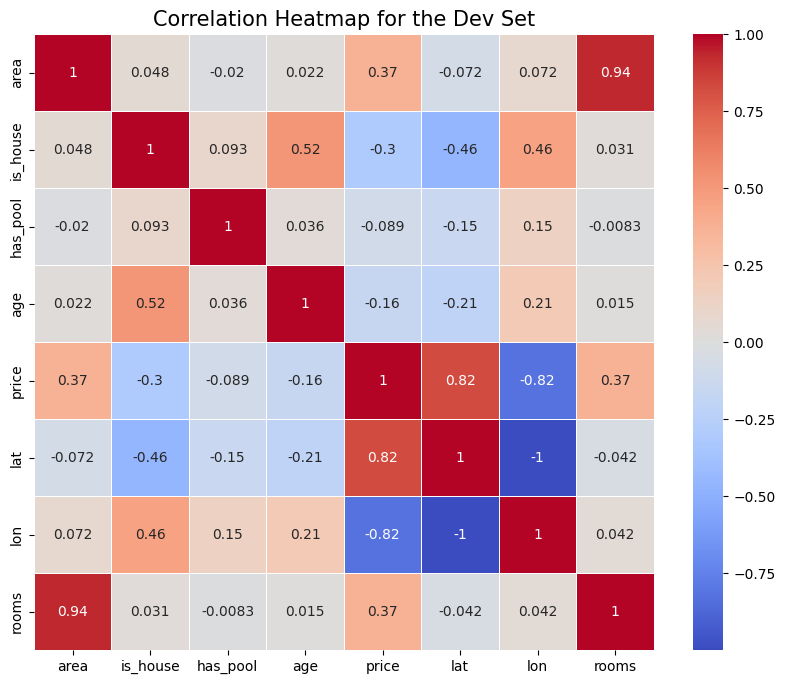

In [16]:
plot_correlation(units_converted_dev_df, "the Dev Set")

#### 1.3) Separación en Train y Validation

Para evitar leaking, separamos el dataset en train y validation antes de estandarizar/escalar los datos y acomodar los valores faltantes.

In [17]:
from src.data_splitting import split_and_save_train_val

In [18]:
train_df, val_df = split_and_save_train_val(units_converted_dev_df, "raw/casas_train.csv", "raw/casas_val.csv")

Train set: 720 rows, Validation set: 180 rows


Ahora continuamos con la estandarización o escalamiento para poder estimar los datos faltantes en el set de train, y nos almacenamos los estadísticos para poder aplicar la misma transformación al set de validación.

#### estandarizamos o escalamos los datos según corresponde

hacemos estandarización (Z-score normalization) cuando asumimos que los datos provienenen de una distribución aproximadamente normal
$$x' = \frac{x - \mu}{\sigma}$$

Y hacemos reescalado cuando cuando los datos no son normales  
Una opción común es Min-Max Scaling:
$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

A partir de la observación de la distribución de las variables decido hacer lo siguiente:  

Estandarizo:  
age (aproximadamente normal), rooms (discreta pero la estandarización ayuda)  
todavía no resolví los nulls así que aún no estandarizo.

Reescalo:   
area y price están sesgadas a la derecha (colas largas)  
la función log anda bien cuando los datos tienen una cola larga hacia la derecha $\rightarrow$ Comprime los valores altos y expande los valores bajos.  
price = log(price + 1) (y hago un ajuste inverso después de la predicción)  
area = log(area + 1) y después estandarizar  
El log hace que los valores grandes no dominen el modelo y mejora la linealidad

No hago nada con las binarias: has_pool, is_house  
lat y lon las analizaremos más adelante con feature engenieering

In [19]:
from src.preprocessing import compute_statistics, scale_df

In [20]:
train_stats = compute_statistics(train_df)

casas_train_transformed = scale_df(train_df, train_stats)
casas_val_transformed = scale_df(val_df, train_stats)
casas_test_transformed = scale_df(units_converted_test_df, train_stats)

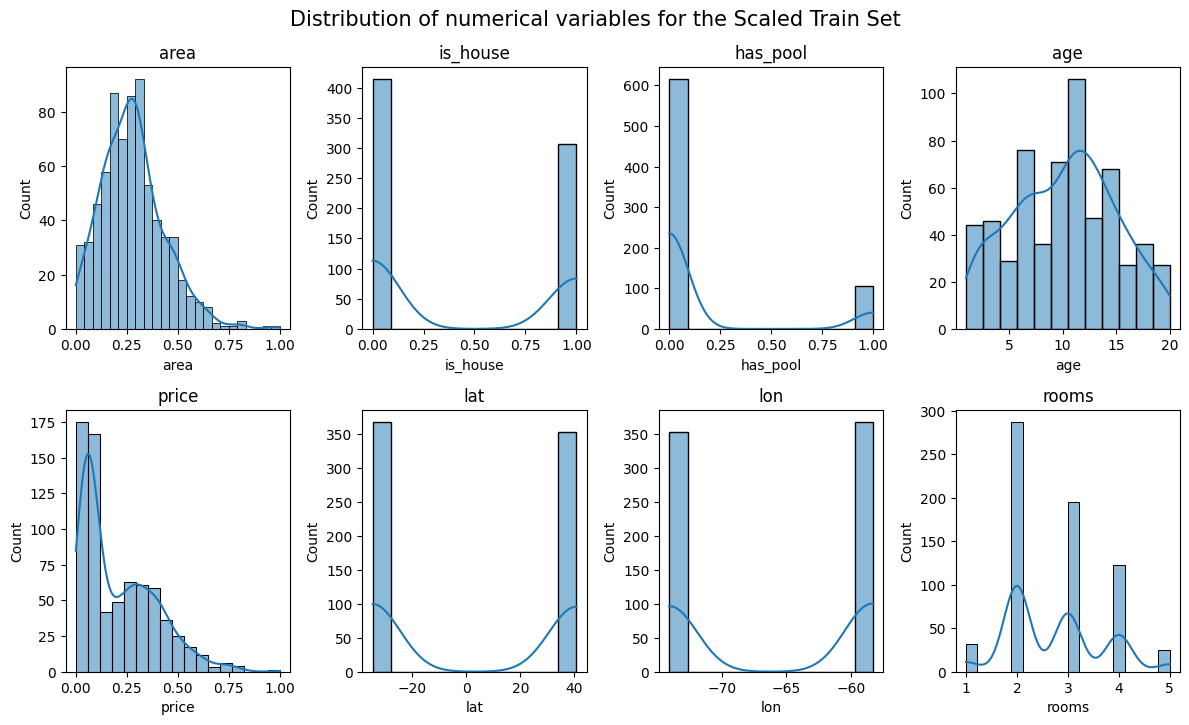

In [21]:
plot_distributions(casas_train_transformed, "Scaled Train")

área y price siguen la misma distribución pero están entre 0 y 1

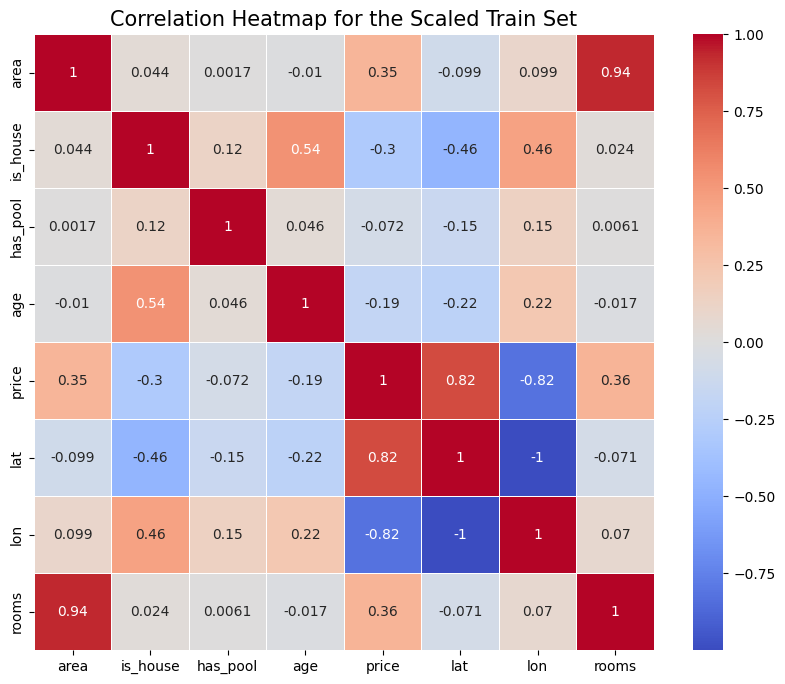

In [22]:
plot_correlation(casas_train_transformed, "the Scaled Train Set")

#### Solucionamos ahora los problemas de nulls

##### Rooms

estimo la cantidad de rooms en base al área

visualizo la relación para ver qué regresión usar

In [23]:
from src.plotting import plot_rooms_vs_area

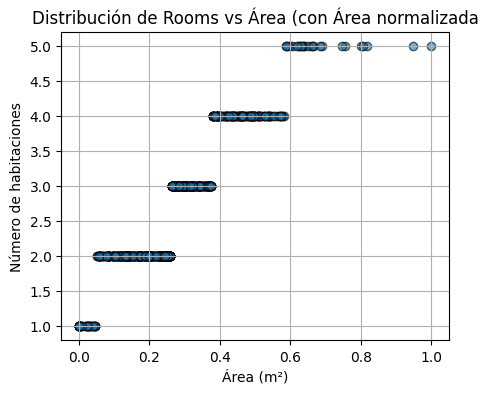

In [24]:
plot_rooms_vs_area(casas_train_transformed, '(con Área normalizada')

In [25]:
from src.models import predict_rooms_train_test, predict_rooms_no_split, complete_missing_rooms_values

ModuleNotFoundError: No module named 'preprocessing'

In [ ]:
# Entrenar en train
print("divididendo el dataset para tener una métrica de precisión (haciendo split de testeo dentro del dataset de train_df)")
predict_rooms_train_test(casas_train_transformed)
print("\nEntrenando con todo el dataset de train_df")
W_d, b_d, mean_d, std_d = predict_rooms_no_split(casas_train_transformed)

# Uso los mismos pesos
print("\nCompletando valores faltantes en todos los datasets con las métricas calculadas a partir de train_df")
casas_train_rooms_complete = complete_missing_rooms_values(casas_train_transformed, W_d, b_d, mean_d, std_d)
casas_val_rooms_complete = complete_missing_rooms_values(casas_val_transformed, W_d, b_d, mean_d, std_d)
casas_test_rooms_complete = complete_missing_rooms_values(casas_test_transformed, W_d, b_d, mean_d, std_d)


divididendo el dataset para tener una métrica de precisión (haciendo split de testeo dentro del dataset de train_df)
Época 0, Pérdida Train: 0.3214, Pérdida Val: 0.3211
Época 5000, Pérdida Train: 0.0578, Pérdida Val: 0.0564
Época 10000, Pérdida Train: 0.0446, Pérdida Val: 0.0428
Época 15000, Pérdida Train: 0.0385, Pérdida Val: 0.0363
Época 20000, Pérdida Train: 0.0348, Pérdida Val: 0.0322
Época 25000, Pérdida Train: 0.0322, Pérdida Val: 0.0294
Precisión en el conjunto de prueba de train_df: 0.9774

Entrenando con todo el dataset de train_df
Época 0, Pérdida Train: 0.3228, Pérdida Val: 0.3228
Época 5000, Pérdida Train: 0.0572, Pérdida Val: 0.0555
Época 10000, Pérdida Train: 0.0442, Pérdida Val: 0.0432
Época 15000, Pérdida Train: 0.0381, Pérdida Val: 0.0376
Época 20000, Pérdida Train: 0.0344, Pérdida Val: 0.0343
Época 25000, Pérdida Train: 0.0318, Pérdida Val: 0.0320

Completando valores faltantes en todos los datasets con las métricas calculadas a partir de train_df
58 valores faltantes

##### Age

estimo las ages que faltan, con aprendizaje supervisado utilizando las features que más correlacion en módulo tienen con age $\rightarrow$ is_house, price, pca_latlon_1

In [ ]:
from src.plotting import plot_age_vs

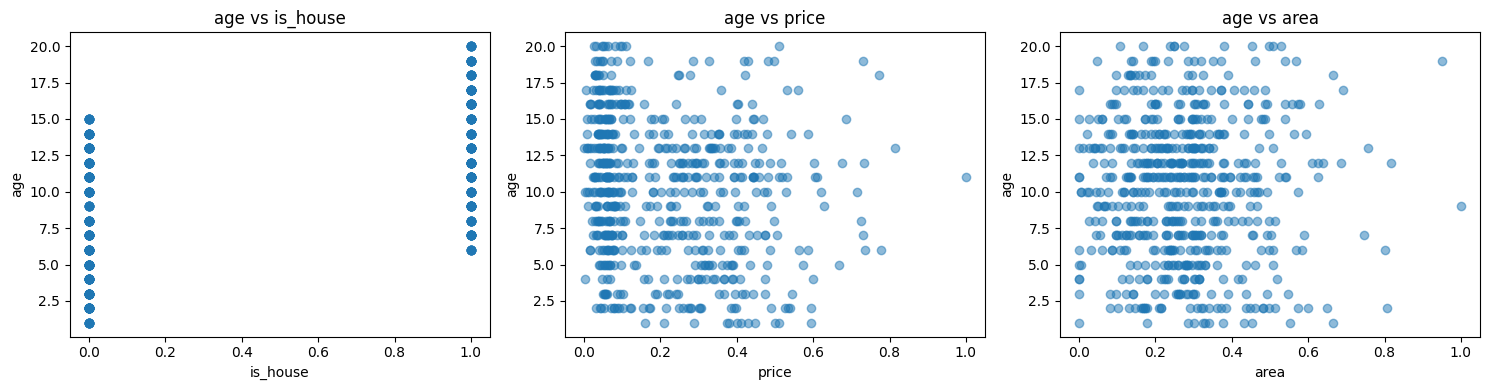

In [ ]:
plot_age_vs(casas_train_rooms_complete, features=["is_house", "price", "area"])

In [ ]:
from src.models import evaluate_complete_model_age, train_regression_for_age, complete_missing_age_values


In [ ]:
features_seleccionadas = ['is_house', 'price', 'area']

# Entrenar evaluando el modelo
theta, mean_train, std_train = evaluate_complete_model_age(casas_train_rooms_complete, features_seleccionadas, grado=1)

# Entrenar con todo el dataset
theta_final, mean_final, std_final = train_regression_for_age(casas_train_rooms_complete, features_seleccionadas, grado=1)

casas_train_complete = complete_missing_age_values(casas_train_rooms_complete, theta_final, mean_final, std_final, features_seleccionadas, grado=1)
casas_val_complete = complete_missing_age_values(casas_val_rooms_complete, theta_final, mean_final, std_final, features_seleccionadas, grado=1)
casas_test_complete = complete_missing_age_values(casas_test_rooms_complete, theta_final, mean_final, std_final, features_seleccionadas, grado=1)


Train RMSE: 4.0405
Validation RMSE: 3.7051
Test RMSE: 4.2650
107 valores faltantes en 'age' completados.
23 valores faltantes en 'age' completados.
16 valores faltantes en 'age' completados.


In [ ]:
complete_train_stats = compute_statistics(casas_train_complete)

casas_train_complete = scale_df(casas_train_complete, complete_train_stats, missing_values=True)
casas_val_complete = scale_df(casas_val_complete, complete_train_stats, missing_values=True)
casas_test_complete = scale_df(casas_test_complete, complete_train_stats, missing_values=True)

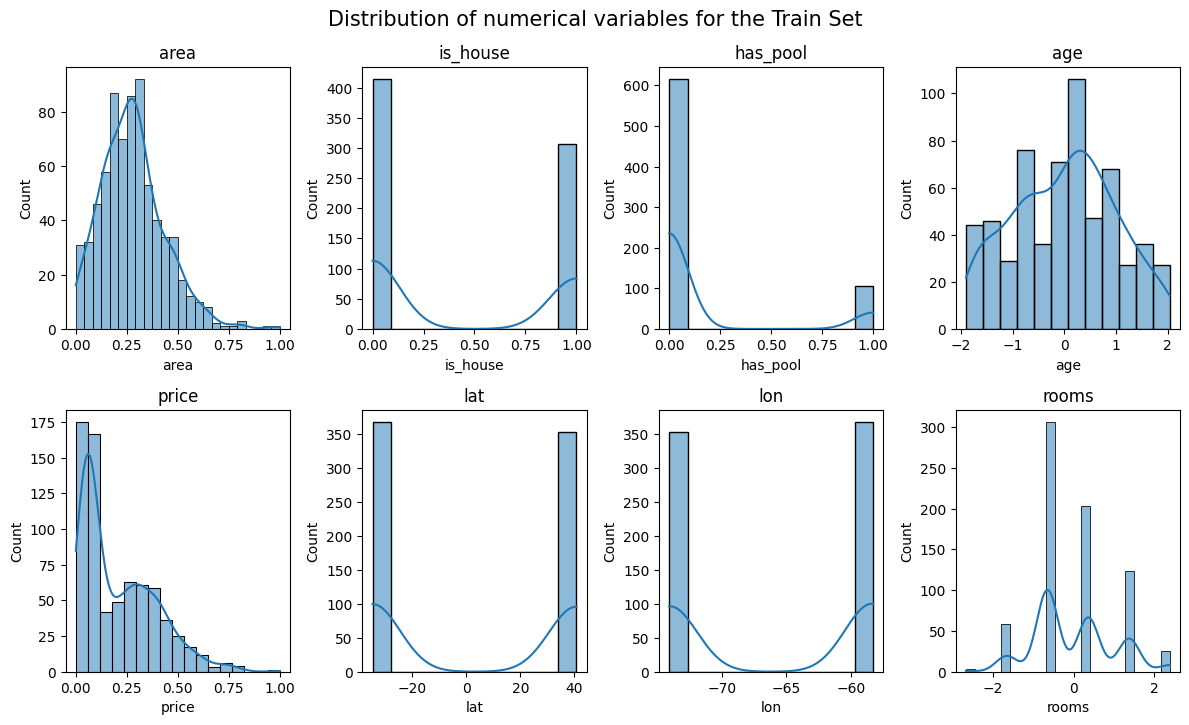

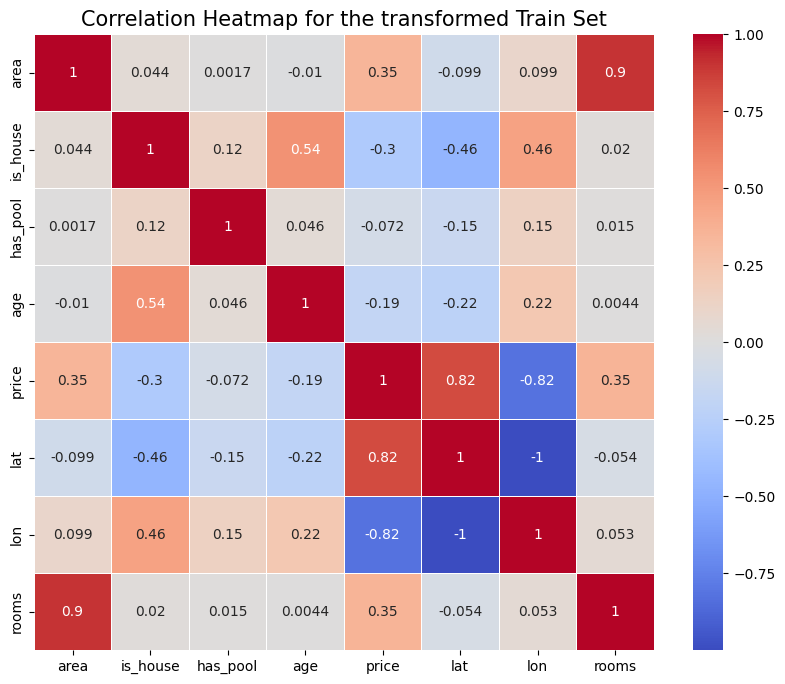

In [ ]:
plot_distributions(casas_train_complete, "Train")
plot_correlation(casas_train_complete, "the transformed Train Set")

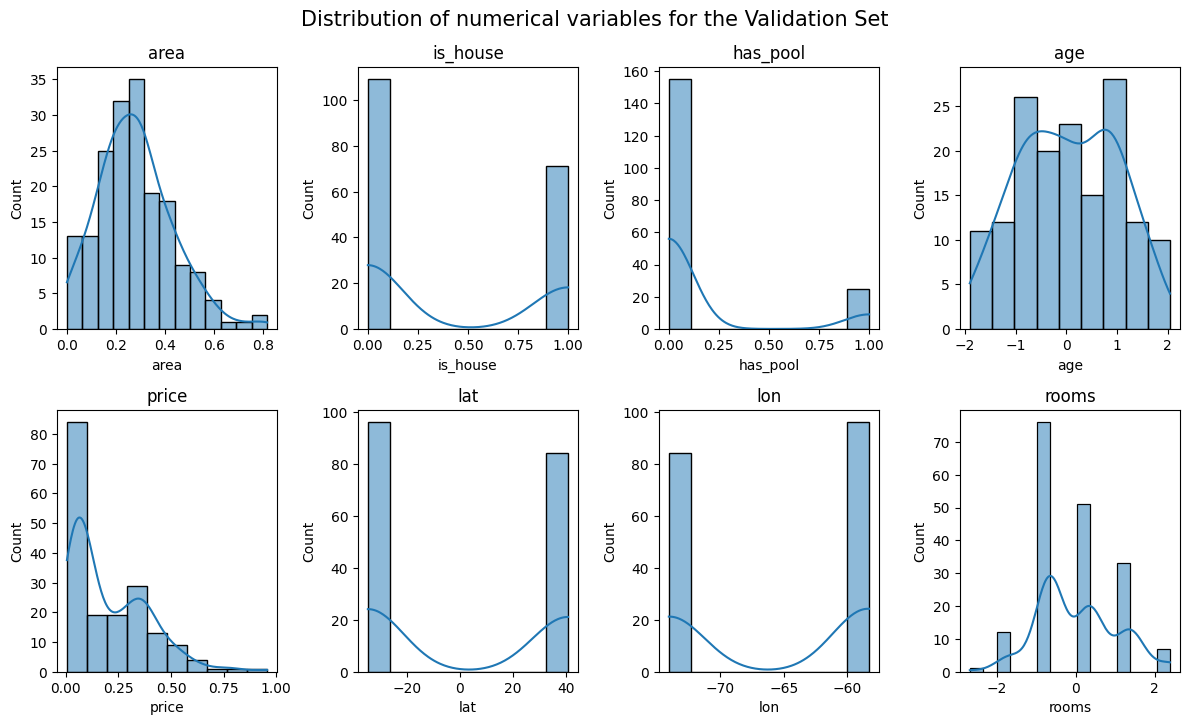

In [ ]:
plot_distributions(casas_val_complete, "Validation")

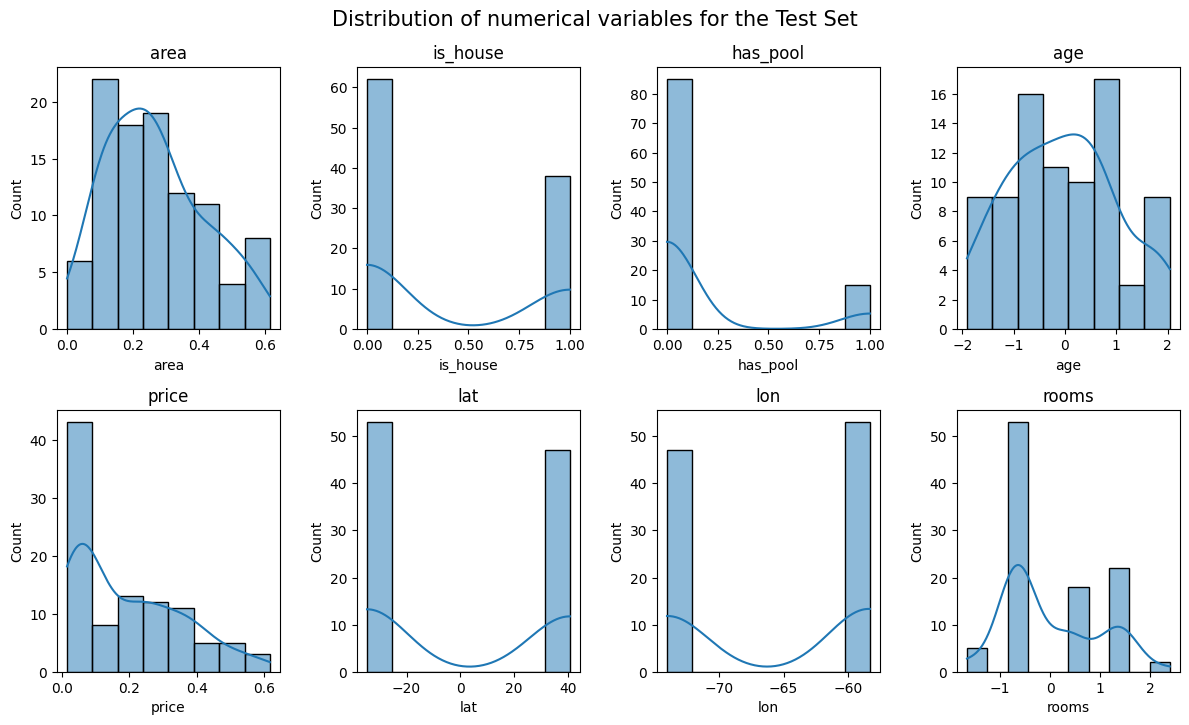

In [ ]:
plot_distributions(casas_test_complete, "Test")

In [ ]:
from src.utils import save_csv

save_csv(casas_train_complete, "data/processed/casas_train_filled_n_normalized.csv")
save_csv(casas_val_complete, "data/processed/casas_val_filled_n_normalized.csv")
save_csv(casas_test_complete, "data/processed/casas_test_filled_n_normalized.csv")


Dataset guardado como 'data/processed/casas_train_filled_n_normalized.csv'.
Dataset guardado como 'data/processed/casas_val_filled_n_normalized.csv'.
Dataset guardado como 'data/processed/casas_test_filled_n_normalized.csv'.


### 2)

implementación de la clase Linear Regression en src.models

In [ ]:
from src.models import LinearRegression
from src.utils import load_data

ImportError: cannot import name 'load_data' from 'src.utils' (c:\Users\anapt\Repositorios\ML-DL\Tissera_AnaPaula_TP1\src\utils.py)

In [ ]:
dir_base = "data/processed/"
train_path = dir_base + "casas_train_filled_n_normalized.csv"
validation_path = dir_base + "casas_val_filled_n_normalized.csv"
test_path = dir_base + "casas_test_filled_n_normalized.csv"

features = ["area", "is_house", "has_pool", "age", "lat", "lon", "rooms"] 
target = "price"

X_train, y_train = load_data(train_path, features, target)

print("NaN en X:", np.isnan(X_train).sum())
print("Inf en X:", np.isinf(X_train).sum())




Coeficientes con una sola característica:
intercepto: 0.0952
area: 0.4094
ECM con una característica: 0.0282


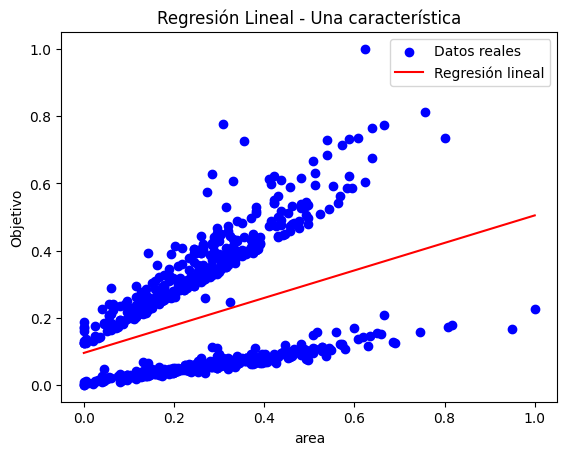

In [ ]:
# Prueba con una característica
# PRUEBA 1: Regresión con una sola característica ("area")
X_1 = X_train[:, [0]]  # Selecciona solo la columna "area"
modelo_1 = LinearRegression(X_1, y_train)
modelo_1.entrenar_pseudoinversa()
print("\nCoeficientes con una sola característica:")
modelo_1.imprimir_coeficientes(["area"])

# Evaluación con ECM
ecm_1 = modelo_1.calcular_ecm(X_1, y_train)
print(f"ECM con una característica: {ecm_1:.4f}")

# Graficar regresión con una sola característica
modelo_1.graficar_regresion(X_1, y_train, ["area"])



In [ ]:

# PRUEBA 2: Regresión con múltiples características
modelo_mult = LinearRegression(X_train, y_train)
modelo_mult.entrenar_pseudoinversa()
print("\nCoeficientes con múltiples características:")
modelo_mult.imprimir_coeficientes(features)

# Evaluación con ECM
ecm_mult = modelo_mult.calcular_ecm(X_train, y_train)
print(f"ECM con múltiples características: {ecm_mult:.4f}")

LinAlgError: SVD did not converge

In [ ]:

# Validación con el conjunto de validación
X_val, y_val = load_data(validation_path, features, target)
error_val = modelo_multi.calcular_ecm(X_val, y_val)
print(f"ECM en validación: {error_val:.4f}")

# Evaluación en el conjunto de prueba
X_test, y_test = load_data(test_path, features, target)
error_test = modelo_multi.calcular_ecm(X_test, y_test)
print(f"ECM en prueba: {error_test:.4f}")

### 3)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Función auxiliar para cargar los datos
def cargar_datos(ruta, features, target):
    df = pd.read_csv(ruta)
    X = df[features].values
    y = df[target].values
    return X, y, df

# Rutas de los archivos
ruta_train = 'casas_train.csv'
ruta_test = 'casas_test_corregido.csv'
ruta_amanda = 'vivienda_Amanda.csv'

# 3.1) Regresión lineal simple (Área -> Precio)
X_train, y_train, df_train = cargar_datos(ruta_train, ['area'], 'price')

# Ajustar el modelo por pseudo-inversa
X_train_bias = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
coef_simple = np.linalg.pinv(X_train_bias) @ y_train

print("Coeficientes (Área -> Precio):", coef_simple)

# Graficar la regresión
plt.scatter(X_train, y_train, color='blue', label='Datos reales')
plt.plot(X_train, X_train_bias @ coef_simple, color='red', label='Regresión')
plt.xlabel('Área')
plt.ylabel('Precio')
plt.title('Regresión Lineal Simple (Área -> Precio)')
plt.legend()
plt.show()

# 3.2) Modelo con múltiples características
features = ['area', 'rooms', 'is_house', 'has_pool']
X_train, y_train, df_train = cargar_datos(ruta_train, features, 'price')
X_test, _, df_test = cargar_datos(ruta_test, features, 'price')
X_amanda, _, _ = cargar_datos(ruta_amanda, features, 'price')

X_train_bias = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
coef_multi = np.linalg.pinv(X_train_bias) @ y_train

print("Coeficientes (Modelo Completo):", coef_multi)

# Predicción para vivienda_Amanda
X_amanda_bias = np.hstack((np.ones((X_amanda.shape[0], 1)), X_amanda))
precio_amanda = X_amanda_bias @ coef_multi
print("Predicción para vivienda Amanda:", precio_amanda)

# 3.3) Valor promedio por metro cuadrado
df_casas = pd.read_csv(ruta_train)
df_casas = df_casas[df_casas['is_house'] == 1]  # Solo casas
precio_m2 = df_casas['price'] / df_casas['area']
print("Valor promedio por metro cuadrado de una casa:", precio_m2.mean())

# 3.4) Impacto de una pileta en el precio
# Consideramos el coeficiente asociado a 'has_pool'
impacto_pileta = coef_multi[features.index('has_pool') + 1]
print("Impacto estimado de construir una pileta en el precio:", impacto_pileta)


In [ ]:
vivienda_Amanda_df = pd.read_csv("data/raw/vivienda_Amanda.csv")
# units_vivienda_Amanda_df = area_units_conversion(vivienda_Amanda_df)
# vivienda_Amanda_scaled = scale_df(units_vivienda_Amanda_df)
# # vivienda_Amanda_transformed = pca_latlon(vivienda_Amanda_scaled)
# vivienda_Amanda_scaled.head(1)
# # vivienda_Amanda_scaled = scale_df(units_vivienda_Amanda_df, missing_values=True)



# # guardar_csv(vivienda_Amanda_transformed, "vivienda_Amanda_corregido.csv")

TypeError: scale_df() missing 1 required positional argument: 'stats'